<a href="https://colab.research.google.com/github/moist234/ECON3916-Statistical-Machine-Learning/blob/main/Project-01/Project1_Phase2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as stm

Shape Audit
Rows: 614, Columns: 11

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  614 non-null    int64  
 1   treat       614 non-null    int64  
 2   age         614 non-null    int64  
 3   educ        614 non-null    int64  
 4   black       614 non-null    int64  
 5   hispan      614 non-null    int64  
 6   married     614 non-null    int64  
 7   nodegree    614 non-null    int64  
 8   re74        614 non-null    float64
 9   re75        614 non-null    float64
 10  re78        614 non-null    float64
dtypes: float64(3), int64(8)
memory usage: 52.9 KB

Descriptive Stats
<bound method NDFrame.describe of      Unnamed: 0  treat  age  educ  black  hispan  married  nodegree  re74  \
0             1      1   37    11      1       0        1         1   0.0   
1             2      1   22     9      0       1        0         1 

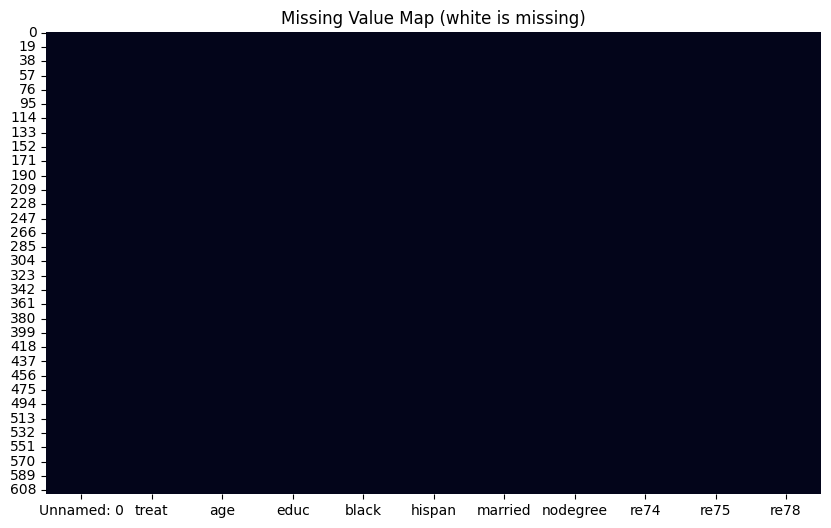

Unnamed: 0    0.0
treat         0.0
age           0.0
educ          0.0
black         0.0
hispan        0.0
married       0.0
nodegree      0.0
re74          0.0
re75          0.0
re78          0.0
dtype: float64


In [23]:
# 2.2 Task 1
df = pd.read_csv('lalonde.csv')
print("Shape Audit")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
print()
df.info()
print()
print("Descriptive Stats")
print(df.describe)

#2.2 Task 2
plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), cbar = False)
plt.title("Missing Value Map (white is missing)")
plt.show()
missing_prcnt = df.isnull().mean() * 100
print(missing_prcnt)

# No data missing?

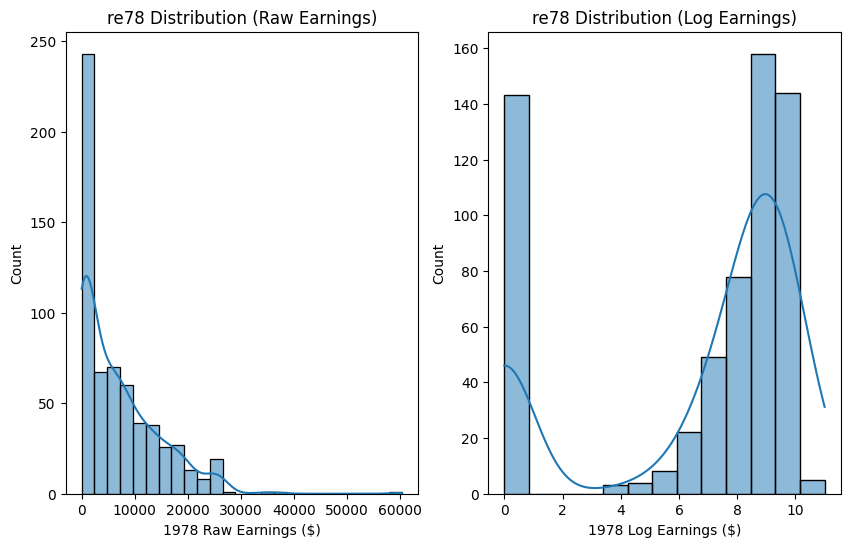

In [24]:
# 2.3 Requiremment 1
plt.figure(figsize=(10,6))
plt.subplot(1,2,1)
sns.histplot(df['re78'], kde=True)
plt.title("re78 Distribution (Raw Earnings)")
plt.xlabel("1978 Raw Earnings ($)")

plt.subplot(1,2,2)
sns.histplot(np.log(df['re78'] + 1), kde=True)
plt.title("re78 Distribution (Log Earnings)")
plt.xlabel("1978 Log Earnings ($)")

plt.show()

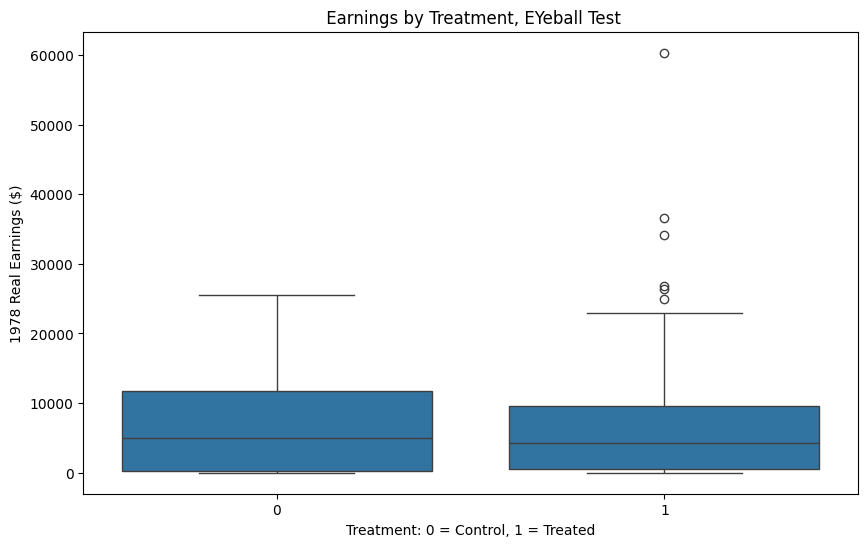

In [25]:
# 2.3 Requirement 2
plt.figure(figsize=(10,6))
sns.boxplot(x='treat', y='re78', data=df)
plt.title(" Earnings by Treatment, EYeball Test")
plt.xlabel("Treatment: 0 = Control, 1 = Treated")
plt.ylabel("1978 Real Earnings ($)")
plt.show()

Turkey Fence Outlier Detection
Q1: 238.28, Q3: 10893.59, IQR: 10655.31
Outliers detected: 3 (0.5% of data)
               re78
count      3.000000
mean   43684.720000
std    14452.369655
min    34099.280000
25%    35373.115000
50%    36646.950000
75%    48477.440000
max    60307.930000


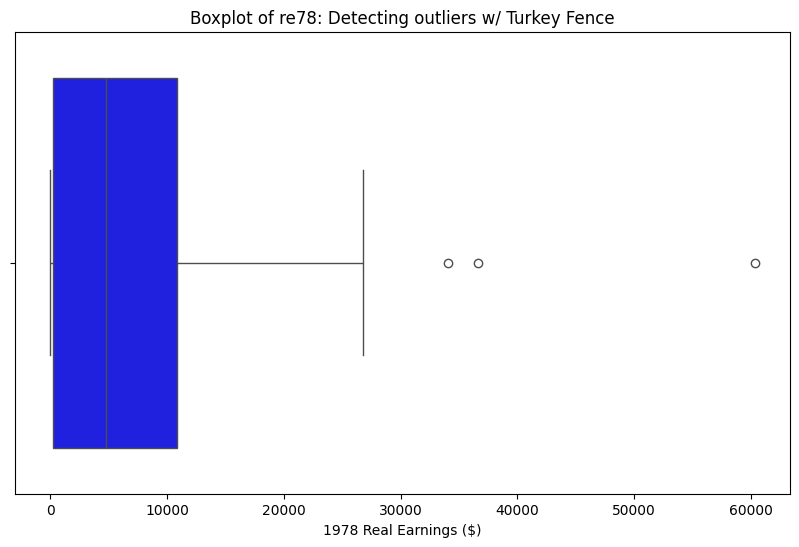

In [26]:
# 2.3 Requirement 3
Q1 = df['re78'].quantile(0.25)
Q3 = df['re78'].quantile(0.75)
IQR = Q3 - Q1

outliers = df[(df['re78'] < (Q1 - 1.5 * IQR)) | (df['re78'] > (Q3 + 1.5 * IQR))]

print(f"Turkey Fence Outlier Detection")
print(f"Q1: {Q1:.2f}, Q3: {Q3:.2f}, IQR: {IQR:.2f}")
print(f"Outliers detected: {len(outliers)} ({len(outliers)/len(df)*100:.1f}% of data)")
print(outliers[['re78']].describe())

plt.figure(figsize=(10,6))
sns.boxplot(x=df['re78'], color='blue')
plt.title("Boxplot of re78: Detecting outliers w/ Turkey Fence")
plt.xlabel("1978 Real Earnings ($)")
plt.show()